# 1. Building $H = -J * H_{zz} - h * H_x$ and $e^{-iHt}$

In [43]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import eigh, expm

#import sys
#print(sys.executable)
#print("Numpy:", np.__version__)

# 1.1 building X and Z

In [44]:
ket0 = np.array([1.0, 0.0], dtype = complex)
ket1 = np.array([0.0, 1.0], dtype = complex)

I = np.eye(2, dtype= complex)


X = np.array([[0.0, 1.0],[1.0, 0.0],], dtype=complex)
Z = np.array([[1.0, 0.0], [0.0, -1.0],], dtype= complex)

In [45]:
assert np.allclose(X @ ket0, ket1)
assert np.allclose(X @ ket1, ket0)
assert np.allclose(Z @ ket0, ket0)
assert np.allclose(Z @ ket1, -ket1)

In [46]:
ket00 = np.kron(ket0, ket0)
ket01 = np.kron(ket0, ket1)
ket10 = np.kron(ket1, ket0)
ket11 = np.kron(ket1, ket1)

basis = [ket00, ket01, ket10, ket11]
basis_labels = ["|00>", "|01>", "|10>", "|11>"]
for label, state in zip(basis_labels, basis):
    print(label, state)

|00> [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|01> [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
|10> [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
|11> [0.+0.j 0.+0.j 0.+0.j 1.+0.j]


In [47]:
XI = np.kron(X, I)
IX = np.kron(I, X)
ZZ = np.kron(Z, Z)
Z0 = np.kron(Z, I)
Z1 = np.kron(I, Z)
X0 = XI
X1 = IX

print("$X \bigotimes I $= ", XI)
print("$I \bigotimes X $= ", IX)
print("$Z \bigotimes Z $= ", ZZ)

$Xigotimes I $=  [[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]
$Iigotimes X $=  [[0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]
$Zigotimes Z $=  [[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j -0.+0.j]
 [ 0.+0.j -0.+0.j -0.+0.j  1.-0.j]]


In [48]:
assert np.allclose(XI @ ket00, ket10)
assert np.allclose(XI @ ket01, ket11)
assert np.allclose(XI @ ket10, ket00)
assert np.allclose(XI @ ket11, ket01)
assert np.allclose(IX @ ket00, ket01)
assert np.allclose(IX @ ket01, ket00)
assert np.allclose(IX @ ket10, ket11)
assert np.allclose(IX @ ket11, ket10)
assert np.allclose(ZZ @ ket00, ket00)
assert np.allclose(ZZ @ ket01, -ket01)
assert np.allclose(ZZ @ ket10, -ket10)
assert np.allclose(ZZ @ ket11, ket11)

In [49]:
def matrix_from_basis(operator, basis):
    columns = []
    for state in basis:
        transformed_state = operator @ state
        columns.append(transformed_state)
    matrix = np.column_stack(columns)
    return matrix

XI_from_basic = matrix_from_basis(XI,basis)
IX_from_basic = matrix_from_basis(IX,basis)
ZZ_from_basic = matrix_from_basis(ZZ,basis)

assert np.allclose(XI_from_basic, XI)
assert np.allclose(IX_from_basic, IX)
assert np.allclose(ZZ_from_basic, ZZ)

In [50]:
J = 1.0
h = 0.7

H_zz = -J * ZZ
H_x  = -h * (XI+IX)
H = H_zz + H_x

print(H)

assert H.shape == (4, 4)
assert np.allclose(H, H.conj().T)

H_expected = np.array(
    [
        [-J, -h, -h, 0.0],
        [-h, J, 0.0, -h],
        [-h, 0.0, J, -h],
        [0.0, -h, -h, -J],
    ],
    dtype = complex,
)

assert np.allclose(H, H_expected)

[[-1. +0.j -0.7+0.j -0.7+0.j -0. +0.j]
 [-0.7+0.j  1. +0.j -0. +0.j -0.7+0.j]
 [-0.7+0.j -0. +0.j  1. +0.j -0.7+0.j]
 [-0. +0.j -0.7+0.j -0.7+0.j -1. +0.j]]


## 1.2. Energy spectropy

In [51]:
#energies, eigenvectors = eigh(H)

In [52]:
Omega = np.sqrt(J**2+4*h**2)
expected_energy = np.array([-Omega, -J, J, Omega])

numerical_energy, eigenvectors = eigh(H)
assert np.allclose(numerical_energy, expected_energy)

In [53]:
def analytic_amplitudes(time, J, h):
    
    Omega = np.sqrt(J**2+4*h**2)
    A = np.cos(Omega * time)+1j*J/Omega*np.sin(Omega*time)
    a00 = 0.5*(np.exp(1j*J*time)+A)
    a11 = 0.5*(-np.exp(1j*J*time)+A)
    a01 = ij*h/Omega*np.sin(Omega*time)
    a10 = a01

    return np.array([a00, a01, a10, a11], stype=complex,)

In [54]:
#psi_numerical = expm(-1j*H*time) @ ket00
#psi_analytic  = analytic_amplitudes(time, J, h)

#assert np.allclose(psi_numerical, psi_analytic)

In [55]:

for index, energy in enumerate(numerical_energy):
    state = eigenvectors[:, index]
    residual = H @ state - energy * state
    assert np.linalg.norm(residual) < 1e-12

print("Eigenvalues:", numerical_energy)
print("Ground-state energy:", numerical_energy[0])

Eigenvalues: [-1.72046505 -1.          1.          1.72046505]
Ground-state energy: -1.7204650534085253


## 1.3. Time evolution

In [56]:
psi0 = np.array([1,0,0,0], dtype=complex)
def evolve_state(
    hamiltonian: np.ndarray, 
    initial_state: np.ndarray, 
    time: float,)->np.ndarray:
    unitary = expm(-1j * hamiltonian * time)
    return unitary @ initial_state

In [57]:
M_z = 0.5*(Z0+Z1)
C_zz = ZZ

def expectation_value(
    state: np.ndarray, 
    operator: np.ndarray, 
)->float: 
    value = np.vdot(state, operator @ state)
    return float(np.real_if_close(value))

In [58]:
times = np.linspace(0.0, 10.0, 201)

magnetizations = []
correlations = []
energies_t = []
norms = []
probabilities = []

for time in times:
    psi_t = evolve_state(H, psi0, time)
    magnetizations.append(expectation_value(psi_t, M_z))
    correlations.append(expectation_value(psi_t, C_zz))
    energies_t.append(expectation_value(psi_t, H))
    norms.append(np.vdot(psi_t, psi_t).real)
    probabilities.append(np.abs(psi_t)**2)
probabilities = np.asarray(probabilities)

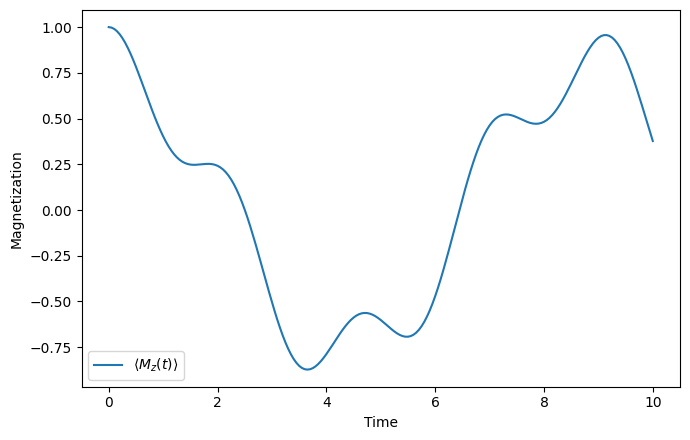

In [59]:
 plt.figure(figsize=(7, 4.5))
plt.plot(times, magnetizations, label=r"$\langle M_z(t)\rangle$")
plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.legend()
plt.tight_layout()
plt.show()

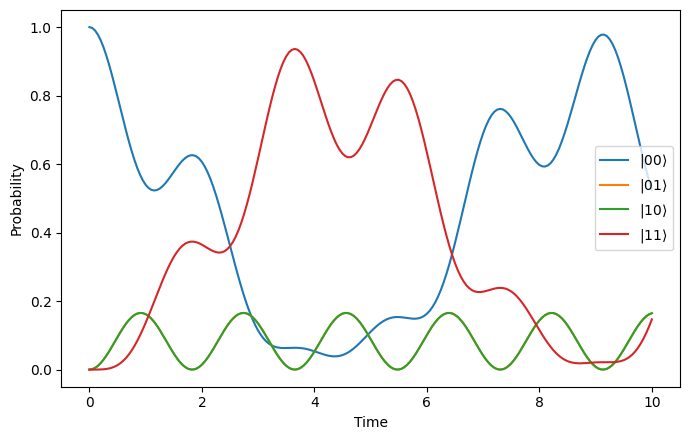

In [60]:
labels = [r"$|00\rangle$", r"$|01\rangle$", r"$|10\rangle$", r"$|11\rangle$"]

plt.figure(figsize=(7, 4.5))

for index, label in enumerate(labels):
    plt.plot(times, probabilities[:, index], label=label)

plt.xlabel("Time")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
assert np.max(np.abs(np.asarray(norms) - 1.0)) < 1e-12
energies_t = np.asarray(energies_t)

assert np.max(np.abs(energies_t - energies_t[0])) < 1e-11
assert np.max(
    np.abs(np.sum(probabilities, axis=1) - 1.0)
) < 1e-12
assert np.max(
    np.abs(probabilities[:, 1] - probabilities[:, 2])
) < 1e-12

In [62]:
H_no_field = -J * ZZ

for time in [0.2, 1.0, 3.0]:
    psi_t = evolve_state(H_no_field, psi0, time)
    assert np.allclose(np.abs(psi_t) ** 2, [1, 0, 0, 0])

    
H_no_interaction = -h * (X0 + X1)

numerical = []

for time in times:
    psi_t = evolve_state(H_no_interaction, psi0, time)
    numerical.append(expectation_value(psi_t, M_z))

analytic = np.cos(2 * h * times)

assert np.max(
    np.abs(np.asarray(numerical) - analytic)
) < 1e-11
